In [5]:
import tensorflow as tf
print ('tensorflow 버전:', tf.__version__)
print()

tensorflow 버전: 2.21.0



In [6]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU 사용 가능! 감지된 GPU: {len(gpus)}개')
    for gpu in gpus:
        print(f'   → {gpu.name}')
else:
    print('⚠️  GPU를 찾을 수 없습니다. CPU로 실행됩니다.')

✅ GPU 사용 가능! 감지된 GPU: 1개
   → /physical_device:GPU:0


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

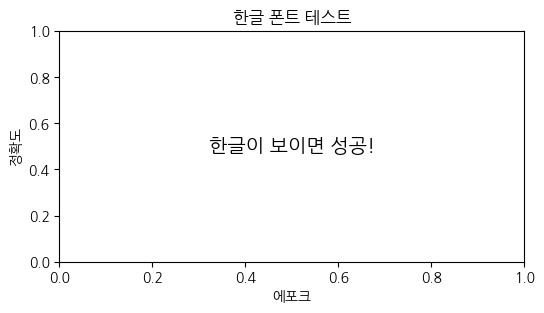

In [9]:
#한글 테스트
plt.figure(figsize=(6, 3))
plt.title('한글 폰트 테스트')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.text(0.5, 0.5, '한글이 보이면 성공!',
         ha='center', va='center', fontsize=14)
plt.show()

# iris

In [11]:
from sklearn import datasets
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [12]:
X_iris = iris.data
y_iris = iris.target

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris,
test_size=0.3, random_state=1)

# ML 에서 신경망 모델 생성

In [19]:
from sklearn.neural_network import MLPClassifier
mlp= MLPClassifier(hidden_layer_sizes=(50,30), activation='logistic',
solver='adam', max_iter=1000)
mlp.fit(X_train, y_train)
#mlp.score(X_test, y_test)
pred = mlp.predict(X_test)

import pandas as pd
import numpy as np
pd.crosstab(pred, y_test) #교차분류표

col_0,0,1,2
row_0,,,
0,14,0,0
1,0,18,0
2,0,0,13


# tensorflow

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential()

model.add(Input(shape=(4,)))
model.add(Dense(50, activation="sigmoid"))
model.add(Dense(30, activation="sigmoid"))
model.add(Dense(3, activation="softmax")) 

In [31]:
model.fit(X_train, y_train, epochs=300, verbose=1)

Epoch 1/300


I0000 00:00:1774504912.958456   29525 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20271__.13


1/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9375 - loss: 0.1242

I0000 00:00:1774504913.654479   29526 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20271__.13


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.9714 - loss: 0.0717
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9810 - loss: 0.0687 
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0709 
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0729 
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9810 - loss: 0.0692 
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0692 
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.0684 
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0686 
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9714 - loss: 0.0682 
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0677 
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9810 - loss: 0.0679 
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0687 


In [33]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step - accuracy: 1.0000 - loss: 0.0181


[0.018073877319693565, 1.0]

# mode compile history

In [32]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
  )
model.history